# Algorithm Evaluation with Full feedback
Considering dataset TH50 for default K values (SELECT k=5, FROM/WHERE k=3)

In [1]:
import os
os.getcwd()
os.chdir('..')

CPU times: user 364 ms, sys: 273 ms, total: 637 ms
Wall time: 2min 8s


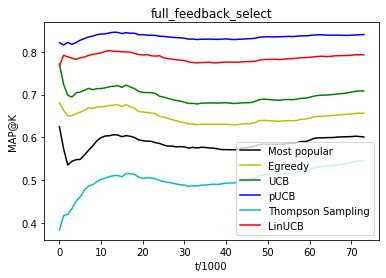

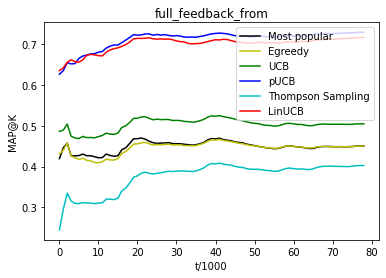

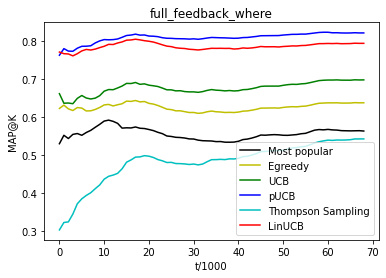

In [6]:
%%time
from sqlcompletions.evaluator import run_n_tests, create_tests
from sqlcompletions.sqlparser import schema



clauses_to_test = [0, 1, 2]
k_to_test = [[5],[3],[3]]
thresholds_to_test = [50]

test_names = ["full_feedback_select", "full_feedback_from", "full_feedback_where"]

db = schema()
results = []
for clause in clauses_to_test:
    tests = []
    for k in k_to_test[clause]:
        for th in thresholds_to_test:
            # ["egreedy", "popular" , "popularPerUser", "ucb", "pucb", "thompson"]
            tests = create_tests(algorithms=["popular", "egreedy","thompson", "ucb", "pucb", "linucb"], clause=clause, top_k = k , db = db , th = th ,feedback=1 )
    
    results.append(run_n_tests(tests,test_names[clause]).results)

## SELECT Clause

In [7]:
results[0]

,Test,MAP@K,Execution Time
3,pUCB,0.84,0.07
5,LinUCB,0.79,0.84
2,UCB,0.71,0.05
1,Egreedy,0.66,0.05
0,Most popular,0.60,0.04
4,Thompson Sampling,0.55,0.09


## FROM Clause

In [8]:
results[1]

,Test,MAP@K,Execution Time
3,pUCB,0.73,0.06
5,LinUCB,0.72,0.53
2,UCB,0.51,0.04
0,Most popular,0.45,0.02
1,Egreedy,0.45,0.04
4,Thompson Sampling,0.40,0.07


### WHERE Clause

In [9]:
results[2]

,Test,MAP@K,Execution Time
3,pUCB,0.82,0.09
5,LinUCB,0.79,0.68
2,UCB,0.70,0.06
1,Egreedy,0.64,0.06
0,Most popular,0.56,0.04
4,Thompson Sampling,0.54,0.10
